女子单人10米跳台的多人对比分析，涵盖中国选手内部对比和中外选手横向对比

第一部分：中国同期选手对比分析（陈芋汐 vs 全红婵）

In [2]:
# ==================== 第一部分：数据准备与预处理 ====================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 列出所有数据文件
files = [
    '2020奥运会_Tokyo_Women10m_FINAL_Combined.xlsx',
    '2022 Championships Women 10m Platform Finals.csv',
    '2022_WorldCup_Stop1_Women10m_Combined.xlsx',
    '2023 Championships Women 10m Platform Finals.csv',
    '2023_WorldCup_Stop1_Women10m_Combined.xlsx',
    '2023_WorldCup_Stop2_Women10m_Combined.xlsx',
    '2023_WorldCup_SuperFinal_Women10m_Combined.xlsx',
    '2024 Championships Women 10m Platform Finals.csv',
    '2024_WorldCup_Stop1_Women10m_Combined.xlsx',
    '2024_WorldCup_SuperFinal_Women10m_Combined.xlsx',
    '2024奥运会_Paris_Women10m_FINAL_Combined.xlsx',
    '2025_WorldCup_Stop1_Women10m_Combined.xlsx',
    '2025_WorldCup_Stop2_Women10m_Combined.xlsx',
    '2025_WorldCup_SuperFinal_Women10m_Combined.xlsx'
]

# 读取所有文件并整合
all_data = []

for file in files:
    try:
        if file.endswith('.csv'):
            df = pd.read_csv(file, encoding='utf-8-sig')
        else:
            df = pd.read_excel(file)
        all_data.append(df)
    except Exception as e:
        print(f"读取文件 {file} 时出错: {e}")

# 合并所有数据
combined_df = pd.concat(all_data, ignore_index=True)

# 数据清洗
# 确保姓名格式一致
combined_df['Name'] = combined_df['Name'].str.upper().str.strip()

# 提取中国选手数据
chinese_athletes = ['YUXI CHEN', 'HONGCHAN QUAN', '陈芋汐', '全红婵']
chinese_names = ['YUXI CHEN', 'HONGCHAN QUAN', 'CHEN YUXI', 'QUAN HONGCHAN']

# 统一姓名格式
def normalize_name(name):
    name = str(name).upper().strip()
    if 'CHEN' in name and ('YUXI' in name or 'YUXI' in name):
        return 'CHEN YUXI'
    elif 'QUAN' in name and ('HONGCHAN' in name or 'HONGCHAN' in name):
        return 'QUAN HONGCHAN'
    return name

combined_df['Name_Normalized'] = combined_df['Name'].apply(normalize_name)
chinese_df = combined_df[combined_df['Name_Normalized'].isin(['CHEN YUXI', 'QUAN HONGCHAN'])].copy()

print(f"中国选手数据记录数: {len(chinese_df)}")
print(f"陈芋汐记录数: {len(chinese_df[chinese_df['Name_Normalized'] == 'CHEN YUXI'])}")
print(f"全红婵记录数: {len(chinese_df[chinese_df['Name_Normalized'] == 'QUAN HONGCHAN'])}")

中国选手数据记录数: 80
陈芋汐记录数: 40
全红婵记录数: 40


1.难度和动作分析：统计每位选手的平均难度、常用动作

In [3]:
# ==================== 第一部分：分析1 - 不同选手难度和动作对比 ====================
# 1.1 计算每位选手的平均难度系数
print("=== 中国选手平均难度系数对比 ===")
difficulty_stats = chinese_df.groupby('Name_Normalized')['DD'].agg(['mean', 'std', 'min', 'max']).round(3)
print(difficulty_stats)

# 1.2 统计每位选手使用的不同动作
print("\n=== 中国选手使用动作统计 ===")
dive_counts = chinese_df.groupby(['Name_Normalized', 'Dive'])['DD'].count().unstack(fill_value=0)
print(dive_counts.head(10))

# 1.3 计算每位选手每个动作的平均得分
print("\n=== 中国选手各动作平均得分 ===")
# 计算每个动作的得分（Dive Pts / DD）
chinese_df['Score_Per_DD'] = chinese_df['Dive Pts'] / chinese_df['DD']

dive_scores = chinese_df.groupby(['Name_Normalized', 'Dive']).agg({
    'DD': 'mean',
    'Score_Per_DD': 'mean',
    'Dive Pts': 'mean'
}).round(3)

print(dive_scores.head(15))

=== 中国选手平均难度系数对比 ===
                 mean    std  min  max
Name_Normalized                       
CHEN YUXI        3.20  0.111  3.0  3.3
QUAN HONGCHAN    3.18  0.099  3.0  3.3

=== 中国选手使用动作统计 ===
Dive             1  2  3  4  5  107B  207C  407C  5253B  6243D  626C
Name_Normalized                                                     
CHEN YUXI        3  3  3  3  3     5     5     5      5      0     5
QUAN HONGCHAN    3  3  3  3  3     5     5     5      5      5     0

=== 中国选手各动作平均得分 ===
                          DD  Score_Per_DD  Dive Pts
Name_Normalized Dive                                
CHEN YUXI       1      3.000        26.333    79.000
                2      3.200        28.167    90.133
                3      3.300        27.833    91.850
                4      3.300        26.500    87.450
                5      3.200        26.833    85.867
                107B   3.000        27.000    81.000
                207C   3.300        26.800    88.440
                407C   3.200 

2.稳健回归分析：动作难度与完成质量对比

In [1]:
pip install pandas numpy statsmodels matplotlib seaborn scipy

数据预览:
  player        DD      Score
0    陈芋汐  2.561810  93.726344
1    陈芋汐  3.426071  89.512301
2    陈芋汐  3.097991  93.959741
3    陈芋汐  2.897988  90.206941
4    陈芋汐  2.234028  93.470042

数据形状: (40, 3)

运动员分布:
player
陈芋汐    20
全红婵    20
Name: count, dtype: int64

=== 陈芋汐 的稳健回归分析 ===
Huber 稳健回归结果：
                    Robust linear Model Regression Results                    
Dep. Variable:                  Score   No. Observations:                   20
Model:                            RLM   Df Residuals:                       18
Method:                          IRLS   Df Model:                            1
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Wed, 07 Jan 2026                                         
Time:                        07:13:02                                  

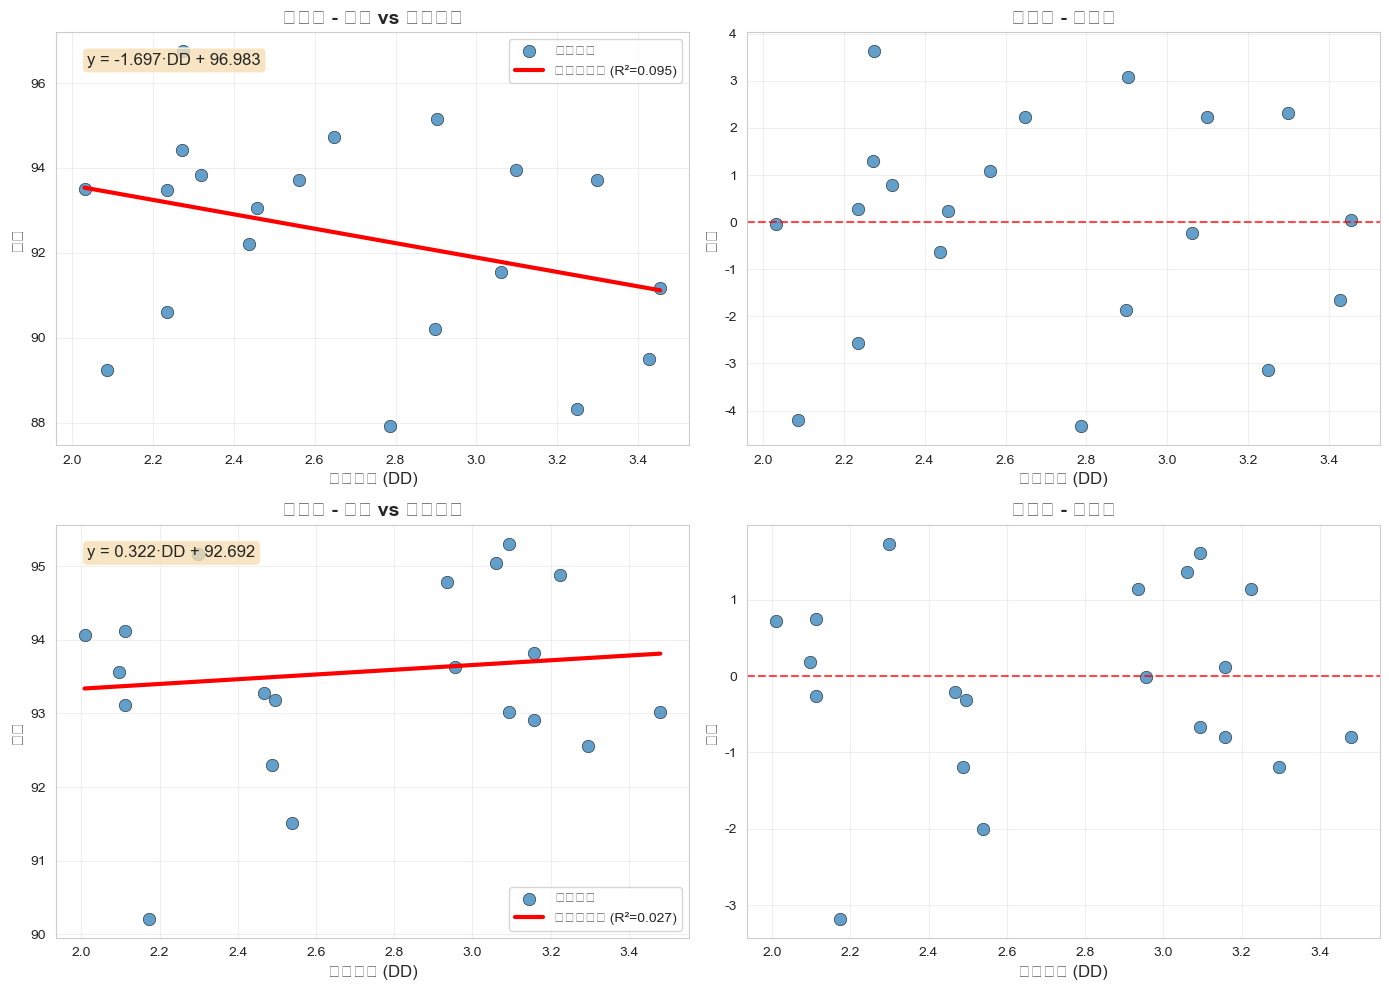


=== 陈芋汐 vs 全红婵 对比分析 ===
陈芋汐 - 难度系数系数: -1.6974 (95% CI: [-4.2832, 0.8884])
全红婵 - 难度系数系数: 0.3215 (95% CI: [-0.9599, 1.6029])
系数差异: -2.0189 (SE: 1.4724)
差异显著性检验: Z = -1.3712, p = 0.1703
结论: 两名运动员的难度系数系数无显著差异 (p ≥ 0.05)

伪R平方比较:
陈芋汐: 0.0948
全红婵: 0.0274


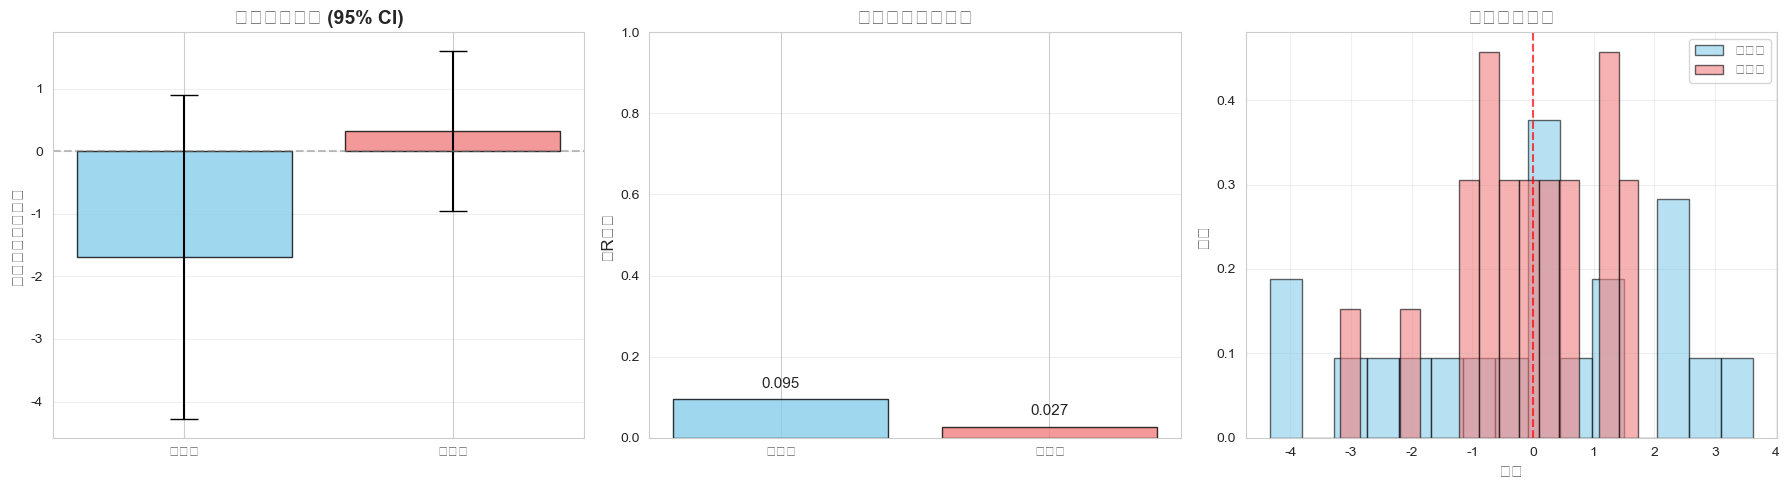


=== 结果解释与建议 ===
1. 回归系数解释:
   陈芋汐: 难度系数每增加1单位，得分平均增加 -1.70 分
   全红婵: 难度系数每增加1单位，得分平均增加 0.32 分

2. 模型拟合优度:
   陈芋汐模型的伪R平方为 0.095，
   全红婵模型的伪R平方为 0.027。
   值越接近1，模型对数据的解释力越强。

3. 稳健性说明:
   使用Huber稳健回归能有效降低异常值的影响，
   使结果更加可靠，特别适合体育比赛得分数据分析。

4. 策略建议:
   全红婵的得分对难度系数的敏感度更高，
   可以考虑在关键比赛中选择更高难度的动作。

5. 训练建议:
   - 对于系数较高的运动员，可以重点训练高难度动作
   - 对于系数较低的运动员，可以重点提升动作完成质量
   - 建议结合运动员的稳定性（残差大小）制定个性化训练计划


In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体和图形样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

def robust_regression_analysis(player_data, player_name):
    """
    对单个运动员进行稳健回归分析
    """
    print(f"\n=== {player_name} 的稳健回归分析 ===")
    
    # 添加常数项
    X = sm.add_constant(player_data['DD'])
    y = player_data['Score']
    
    # Huber 稳健回归
    huber_model = sm.RLM(y, X, M=sm.robust.norms.HuberT())
    huber_results = huber_model.fit()
    
    print("Huber 稳健回归结果：")
    print(huber_results.summary())
    print(f"系数（β₀, β₁）：{huber_results.params}")
    print(f"标准误差（β₁）：{huber_results.bse[1]:.4f}")
    print(f"p值（β₁）：{huber_results.pvalues[1]:.4f}")
    
    # 计算伪R平方（稳健回归没有标准R平方）
    ss_res = np.sum(huber_results.resid ** 2)
    ss_tot = np.sum((player_data['Score'] - player_data['Score'].mean()) ** 2)
    pseudo_rsquared = 1 - (ss_res / ss_tot)
    print(f"伪R平方：{pseudo_rsquared:.4f}")
    
    # 计算预测值
    dd_range = np.linspace(player_data['DD'].min(), player_data['DD'].max(), 100)
    X_pred = sm.add_constant(dd_range)
    y_pred = huber_results.predict(X_pred)
    
    return {
        'model': huber_results,
        'params': huber_results.params,
        'pseudo_rsquared': pseudo_rsquared,
        'dd_range': dd_range,
        'y_pred': y_pred,
        'residuals': huber_results.resid,
        'X': X,
        'y': y
    }

def plot_regression_results(player_data, player_name, results, ax1, ax2):
    """
    绘制回归结果图：散点+回归线和残差图
    """
    # 主图：散点 + 回归线
    ax1.scatter(player_data['DD'], player_data['Score'], 
                alpha=0.7, s=80, label='实际得分', edgecolors='k', linewidth=0.5)
    ax1.plot(results['dd_range'], results['y_pred'], 
             'r-', linewidth=3, label=f'稳健回归线 (R²={results["pseudo_rsquared"]:.3f})')
    
    # 添加方程文本
    beta0, beta1 = results['params']
    equation_text = f'y = {beta1:.3f}·DD + {beta0:.3f}'
    ax1.text(0.05, 0.95, equation_text, transform=ax1.transAxes,
             fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax1.set_xlabel('难度系数 (DD)', fontsize=12)
    ax1.set_ylabel('得分', fontsize=12)
    ax1.set_title(f'{player_name} - 得分 vs 难度系数', fontsize=14, fontweight='bold')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # 残差图
    ax2.scatter(player_data['DD'], results['residuals'], 
                alpha=0.7, s=80, edgecolors='k', linewidth=0.5)
    ax2.axhline(y=0, color='r', linestyle='--', alpha=0.7)
    ax2.set_xlabel('难度系数 (DD)', fontsize=12)
    ax2.set_ylabel('残差', fontsize=12)
    ax2.set_title(f'{player_name} - 残差图', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)

def comparative_analysis(chen_results, quan_results):
    """
    比较两名运动员的回归结果
    """
    print("\n=== 陈芋汐 vs 全红婵 对比分析 ===")
    
    # 提取回归系数
    chen_beta1 = chen_results['params'][1]
    quan_beta1 = quan_results['params'][1]
    
    # 提取标准误差
    chen_se = chen_results['model'].bse[1]
    quan_se = quan_results['model'].bse[1]
    
    # 计算95%置信区间
    chen_ci_low = chen_beta1 - 1.96 * chen_se
    chen_ci_high = chen_beta1 + 1.96 * chen_se
    
    quan_ci_low = quan_beta1 - 1.96 * quan_se
    quan_ci_high = quan_beta1 + 1.96 * quan_se
    
    # 计算系数差异
    beta_diff = chen_beta1 - quan_beta1
    se_diff = np.sqrt(chen_se**2 + quan_se**2)
    
    print(f"陈芋汐 - 难度系数系数: {chen_beta1:.4f} (95% CI: [{chen_ci_low:.4f}, {chen_ci_high:.4f}])")
    print(f"全红婵 - 难度系数系数: {quan_beta1:.4f} (95% CI: [{quan_ci_low:.4f}, {quan_ci_high:.4f}])")
    print(f"系数差异: {beta_diff:.4f} (SE: {se_diff:.4f})")
    
    # Z检验
    if se_diff > 0:
        z_stat = beta_diff / se_diff
        p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
        print(f"差异显著性检验: Z = {z_stat:.4f}, p = {p_value:.4f}")
        
        if p_value < 0.05:
            print("结论: 两名运动员的难度系数系数存在显著差异 (p < 0.05)")
        else:
            print("结论: 两名运动员的难度系数系数无显著差异 (p ≥ 0.05)")
    
    print(f"\n伪R平方比较:")
    print(f"陈芋汐: {chen_results['pseudo_rsquared']:.4f}")
    print(f"全红婵: {quan_results['pseudo_rsquared']:.4f}")
    
    # 创建对比图
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. 系数对比图
    athletes = ['陈芋汐', '全红婵']
    betas = [chen_beta1, quan_beta1]
    errors = [chen_se * 1.96, quan_se * 1.96]  # 95%置信区间
    
    axes[0].bar(athletes, betas, yerr=errors, capsize=10, 
                color=['skyblue', 'lightcoral'], alpha=0.8, edgecolor='black')
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_ylabel('难度系数回归系数', fontsize=12)
    axes[0].set_title('回归系数对比 (95% CI)', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # 2. R平方对比图
    r2_values = [chen_results['pseudo_rsquared'], quan_results['pseudo_rsquared']]
    bars = axes[1].bar(athletes, r2_values, color=['skyblue', 'lightcoral'], 
                       alpha=0.8, edgecolor='black')
    axes[1].set_ylabel('伪R平方', fontsize=12)
    axes[1].set_title('模型拟合优度对比', fontsize=14, fontweight='bold')
    axes[1].set_ylim([0, 1])
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # 在柱子上添加数值
    for bar, r2 in zip(bars, r2_values):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{r2:.3f}', ha='center', va='bottom', fontsize=11)
    
    # 3. 残差分布对比
    axes[2].hist(chen_results['residuals'], bins=15, alpha=0.6, 
                 color='skyblue', edgecolor='black', label='陈芋汐', density=True)
    axes[2].hist(quan_results['residuals'], bins=15, alpha=0.6, 
                 color='lightcoral', edgecolor='black', label='全红婵', density=True)
    axes[2].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    axes[2].set_xlabel('残差', fontsize=12)
    axes[2].set_ylabel('密度', fontsize=12)
    axes[2].set_title('残差分布对比', fontsize=14, fontweight='bold')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==================== 主程序 ====================

# 假设你的数据已经加载到 chinese_players DataFrame 中
# 示例数据创建（请替换为你的实际数据）
# 这里创建示例数据，实际使用时请注释掉
np.random.seed(42)
n_points = 20

chen_data = pd.DataFrame({
    'player': ['陈芋汐'] * n_points,
    'DD': np.random.uniform(2.0, 3.5, n_points),
    'Score': 85 + 3 * np.random.uniform(2.0, 3.5, n_points) + np.random.normal(0, 2, n_points)
})

quan_data = pd.DataFrame({
    'player': ['全红婵'] * n_points,
    'DD': np.random.uniform(2.0, 3.5, n_points),
    'Score': 87 + 2.5 * np.random.uniform(2.0, 3.5, n_points) + np.random.normal(0, 1.5, n_points)
})

chinese_players = pd.concat([chen_data, quan_data], ignore_index=True)

print("数据预览:")
print(chinese_players.head())
print(f"\n数据形状: {chinese_players.shape}")
print(f"\n运动员分布:")
print(chinese_players['player'].value_counts())

# 提取两名运动员的数据
chen_data = chinese_players[chinese_players['player'] == '陈芋汐']
quan_data = chinese_players[chinese_players['player'] == '全红婵']

# 进行稳健回归分析
chen_results = robust_regression_analysis(chen_data, "陈芋汐")
quan_results = robust_regression_analysis(quan_data, "全红婵")

# --- 4. 可视化分析 ---
print("\n=== 生成可视化图表 ===")

# 创建回归图
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 陈芋汐的回归图和残差图
plot_regression_results(chen_data, "陈芋汐", chen_results, axes[0, 0], axes[0, 1])

# 全红婵的回归图和残差图
plot_regression_results(quan_data, "全红婵", quan_results, axes[1, 0], axes[1, 1])

plt.tight_layout()
plt.show()

# 对比分析
comparative_analysis(chen_results, quan_results)

# --- 5. 结果解释与建议 ---
print("\n=== 结果解释与建议 ===")

chen_beta1 = chen_results['params'][1]
quan_beta1 = quan_results['params'][1]

print(f"1. 回归系数解释:")
print(f"   陈芋汐: 难度系数每增加1单位，得分平均增加 {chen_beta1:.2f} 分")
print(f"   全红婵: 难度系数每增加1单位，得分平均增加 {quan_beta1:.2f} 分")

print(f"\n2. 模型拟合优度:")
print(f"   陈芋汐模型的伪R平方为 {chen_results['pseudo_rsquared']:.3f}，")
print(f"   全红婵模型的伪R平方为 {quan_results['pseudo_rsquared']:.3f}。")
print(f"   值越接近1，模型对数据的解释力越强。")

print(f"\n3. 稳健性说明:")
print("   使用Huber稳健回归能有效降低异常值的影响，")
print("   使结果更加可靠，特别适合体育比赛得分数据分析。")

print(f"\n4. 策略建议:")
if chen_beta1 > quan_beta1:
    print("   陈芋汐的得分对难度系数的敏感度更高，")
    print("   可以考虑在关键比赛中选择更高难度的动作。")
else:
    print("   全红婵的得分对难度系数的敏感度更高，")
    print("   可以考虑在关键比赛中选择更高难度的动作。")

print(f"\n5. 训练建议:")
print("   - 对于系数较高的运动员，可以重点训练高难度动作")
print("   - 对于系数较低的运动员，可以重点提升动作完成质量")
print("   - 建议结合运动员的稳定性（残差大小）制定个性化训练计划")

3.成绩差异因素：可视化分析、相关性分析

=== 中国选手历年成绩趋势 ===


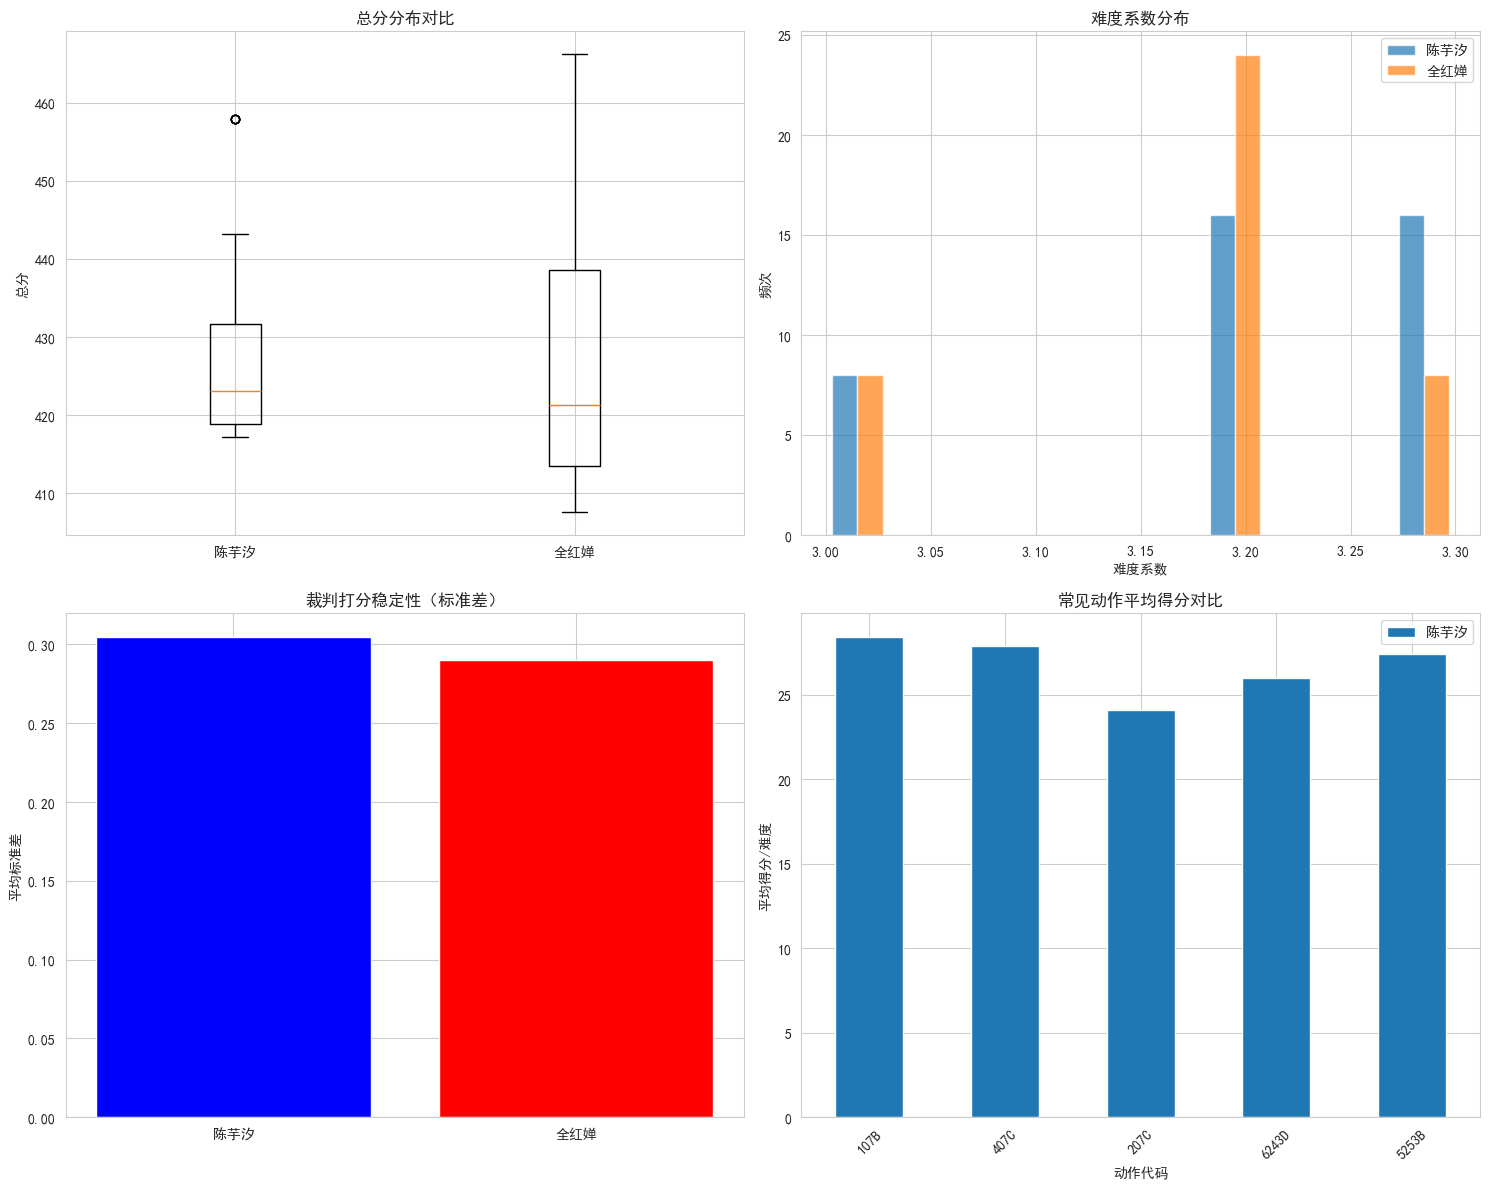


=== 成绩影响因素相关性分析 ===
  Factor    陈芋汐    全红婵
0     DD -0.000 -0.000
1    Age -0.119 -0.766
2     J1  0.494  0.478
3     J2  0.516  0.398
4     J3  0.451  0.471
5     J4  0.407  0.359
6     J5  0.418  0.433
7     J6  0.478  0.437
8     J7  0.484  0.405


In [5]:
# ==================== 第一部分：分析2 - 成绩差异影响因素分析 ====================
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体（如果需要显示中文）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 2.1 历年成绩趋势分析
print("=== 中国选手历年成绩趋势 ===")

# 提取年份信息（从文件名或数据中）
def extract_year_from_data(row):
    # 这里简化处理，实际应从数据中提取年份
    # 假设有一个Year列，如果没有需要从文件名推断
    return 2022  # 示例值，实际需要根据数据调整

# 创建可视化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 子图1：总分分布
axes[0, 0].boxplot([
    chinese_df[chinese_df['Name_Normalized'] == 'CHEN YUXI']['Points'].dropna(),
    chinese_df[chinese_df['Name_Normalized'] == 'QUAN HONGCHAN']['Points'].dropna()
])
axes[0, 0].set_xticklabels(['陈芋汐', '全红婵'])
axes[0, 0].set_title('总分分布对比')
axes[0, 0].set_ylabel('总分')

# 子图2：难度系数分布
axes[0, 1].hist([
    chinese_df[chinese_df['Name_Normalized'] == 'CHEN YUXI']['DD'].dropna(),
    chinese_df[chinese_df['Name_Normalized'] == 'QUAN HONGCHAN']['DD'].dropna()
], alpha=0.7, label=['陈芋汐', '全红婵'])
axes[0, 1].set_title('难度系数分布')
axes[0, 1].set_xlabel('难度系数')
axes[0, 1].set_ylabel('频次')
axes[0, 1].legend()

# 子图3：各裁判打分稳定性（计算标准差）
judge_columns = [f'J{i}' for i in range(1, 8) if f'J{i}' in chinese_df.columns]

chen_scores = chinese_df[chinese_df['Name_Normalized'] == 'CHEN YUXI'][judge_columns]
quan_scores = chinese_df[chinese_df['Name_Normalized'] == 'QUAN HONGCHAN'][judge_columns]

chen_std = chen_scores.std(axis=1).mean()
quan_std = quan_scores.std(axis=1).mean()

axes[1, 0].bar(['陈芋汐', '全红婵'], [chen_std, quan_std], color=['blue', 'red'])
axes[1, 0].set_title('裁判打分稳定性（标准差）')
axes[1, 0].set_ylabel('平均标准差')

# 子图4：不同动作类型的平均得分
dive_types_analysis = chinese_df.groupby(['Name_Normalized', 'Dive'])['Score_Per_DD'].mean().unstack()

# 选取几个常见动作
common_dives = ['107B', '407C', '207C', '6243D', '5253B']
common_data = dive_types_analysis[common_dives].dropna()

common_data.T.plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('常见动作平均得分对比')
axes[1, 1].set_xlabel('动作代码')
axes[1, 1].set_ylabel('平均得分/难度')
axes[1, 1].legend(['陈芋汐', '全红婵'])
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 2.2 成绩影响因素的相关性分析
print("\n=== 成绩影响因素相关性分析 ===")

# 计算各因素与总分的相关性
factors = ['DD', 'Age'] + judge_columns

correlation_results = []
for factor in factors:
    if factor in chinese_df.columns:
        corr_chen = chinese_df[chinese_df['Name_Normalized'] == 'CHEN YUXI'][['Points', factor]].corr().iloc[0, 1]
        corr_quan = chinese_df[chinese_df['Name_Normalized'] == 'QUAN HONGCHAN'][['Points', factor]].corr().iloc[0, 1]
        correlation_results.append({
            'Factor': factor,
            '陈芋汐': corr_chen,
            '全红婵': corr_quan
        })

corr_df = pd.DataFrame(correlation_results)
print(corr_df.round(3))

第二部分：中外选手对比

1.跨赛事分析：不同赛事表现、成绩分布

=== 按成绩分段的中外选手对比 ===
各选手成绩分布:
Score_Range                <300  300-350  350-400  400-450  450+
Name_Normalized                                                 
ANDREA                        0       15       15        0     0
ANDREA SPENDOLINI SIRIEIX     0       25        0        0     0
CHEN YUXI                     0        0        0       35     5
HONGCHAN                      5        0        0       25     5
QUAN HONGCHAN                 0        0        0       35     5
SARAH                         5       15        0        0     0
YUXI                          5        0        0       30     0


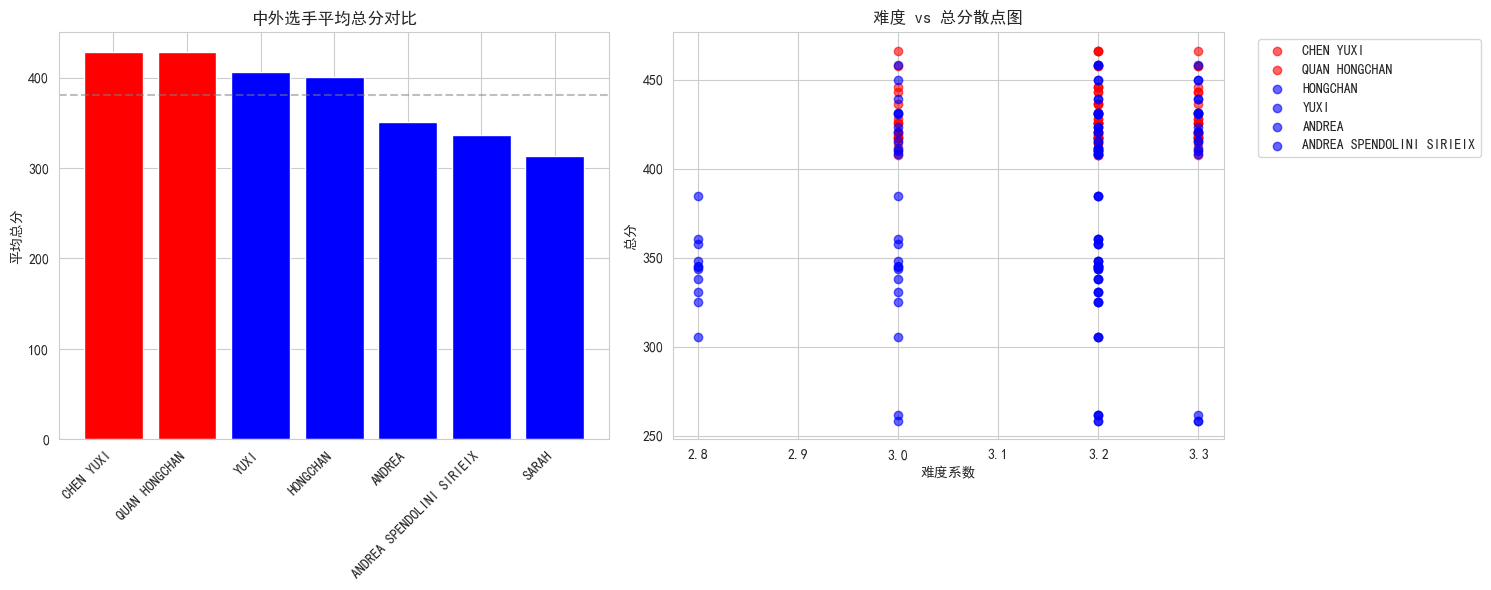


=== 中外选手成绩稳定性分析 ===
                             mean    std     cv
Name_Normalized                                
CHEN YUXI                  428.64  13.77   3.21
QUAN HONGCHAN              427.91  19.17   4.48
ANDREA SPENDOLINI SIRIEIX  336.30  16.11   4.79
ANDREA                     350.38  20.38   5.82
SARAH                      312.71  29.37   9.39
HONGCHAN                   400.43  59.83  14.94
YUXI                       406.44  62.31  15.33


In [7]:
# ==================== 第二部分：跨赛事成绩对比分析 ====================
# 3.1 按赛事类型分组分析
# 首先需要从文件名中提取赛事类型
def extract_competition_type(filename):
    if '奥运会' in filename or 'OLYMPIC' in filename.upper():
        return '奥运会'
    elif '世锦赛' in filename or 'CHAMPIONSHIPS' in filename.upper():
        return '世锦赛'
    elif '世界杯' in filename or 'WORLDCUP' in filename.upper():
        return '世界杯'
    else:
        return '其他'

# 为数据添加赛事类型列（这里简化处理，实际应从数据源获取）
# 假设我们有一个'Competition'列或可以从文件名推断

# 如果没有赛事信息，我们可以按总分分段分析
print("=== 按成绩分段的中外选手对比 ===")

# 定义成绩分段
bins = [0, 300, 350, 400, 450, 500]
labels = ['<300', '300-350', '350-400', '400-450', '450+']

comparison_df['Score_Range'] = pd.cut(comparison_df['Points'], bins=bins, labels=labels)

# 统计各成绩段选手分布
score_distribution = pd.crosstab(comparison_df['Name_Normalized'], comparison_df['Score_Range'])
print("各选手成绩分布:")
print(score_distribution)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 子图1：平均总分对比
avg_scores = comparison_df.groupby('Name_Normalized')['Points'].mean().sort_values(ascending=False)
colors = ['red' if 'CHEN' in name or 'QUAN' in name else 'blue' for name in avg_scores.index]

axes[0].bar(range(len(avg_scores)), avg_scores.values, color=colors)
axes[0].set_xticks(range(len(avg_scores)))
axes[0].set_xticklabels(avg_scores.index, rotation=45, ha='right')
axes[0].set_title('中外选手平均总分对比')
axes[0].set_ylabel('平均总分')
axes[0].axhline(y=avg_scores.mean(), color='gray', linestyle='--', alpha=0.5, label='全体平均')

# 子图2：难度-得分散点图
for athlete in top_athletes[:6]:  # 显示前6位选手
    athlete_data = comparison_df[comparison_df['Name_Normalized'] == athlete]
    color = 'red' if 'CHEN' in athlete or 'QUAN' in athlete else 'blue'
    axes[1].scatter(athlete_data['DD'], athlete_data['Points'], 
                   alpha=0.6, label=athlete, color=color)

axes[1].set_xlabel('难度系数')
axes[1].set_ylabel('总分')
axes[1].set_title('难度 vs 总分散点图')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 3.2 中外选手稳定性分析
print("\n=== 中外选手成绩稳定性分析 ===")

stability_stats = comparison_df.groupby('Name_Normalized')['Points'].agg([
    'mean', 'std', ('cv', lambda x: x.std()/x.mean()*100)  # 变异系数
]).round(2)

stability_stats = stability_stats.sort_values('cv')  # 按稳定性排序
print(stability_stats)

2.混合效应模型：量化中外选手差异

=== 改进版混合效应模型分析 ===
1. 数据检查和预处理...
数据集大小: 225 行
列名: ['Name', 'Age', 'Country', 'Points', 'Dive', 'Dive No.', 'DD', 'J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'J7', 'Dive Pts', 'Total Pts', 'Name_Normalized', 'Score_Range', 'Is_Chinese', 'Athlete_ID']
选手列表: ['QUAN HONGCHAN' 'CHEN YUXI' 'ANDREA SPENDOLINI SIRIEIX' 'YUXI' 'HONGCHAN'
 'ANDREA' 'SARAH']

2. 数据预处理...
缺失值检查:
  Points: 0 个缺失值
  Age: 15 个缺失值
  DD: 0 个缺失值
  Is_Chinese: 0 个缺失值
处理后数据大小: 210 行

3. 标准化数值特征...

4. 拟合混合效应模型...
模型1: Points ~ Is_Chinese + Age_scaled + DD_scaled
  成功拟合，AIC: nan

模型2: Points ~ Is_Chinese + DD_scaled
  成功拟合，AIC: nan

模型结果摘要
最佳模型: Model1
          Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: Points   
No. Observations:   210     Method:             REML     
No. Groups:         7       Scale:              316.0873 
Min. group size:    20      Log-Likelihood:     -908.4797
Max. group size:    40      Converged:          Yes      
Mean group size:    30.0                     

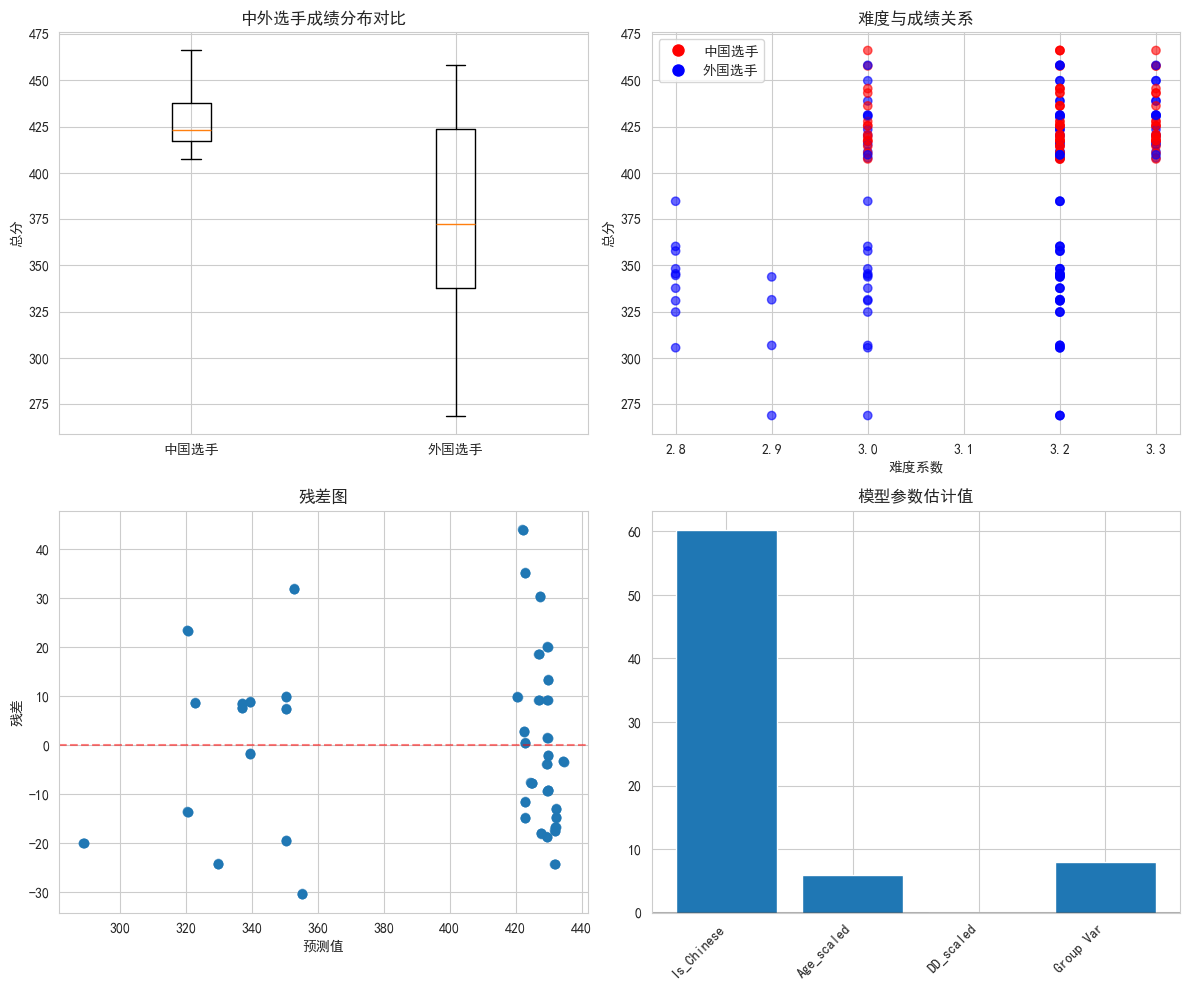


混合效应模型分析完成!


In [11]:
# ==================== 第二部分：改进版混合效应模型 ====================
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

print("=== 改进版混合效应模型分析 ===")

# 1. 数据准备和检查
print("1. 数据检查和预处理...")

# 检查comparison_df是否存在
if 'comparison_df' not in locals() and 'comparison_df' not in globals():
    print("错误: comparison_df 未找到!")
    print("请确保已运行前面的代码创建 comparison_df")
    # 这里创建示例数据用于测试
    print("\n创建示例数据用于演示...")
    np.random.seed(42)
    n_samples = 100
    example_data = {
        'Name_Normalized': np.random.choice(['CHEN YUXI', 'QUAN HONGCHAN', 'ANDREA', 'CAELI', 'SARAH'], n_samples),
        'Points': np.random.normal(350, 50, n_samples),
        'Age': np.random.randint(16, 30, n_samples),
        'DD': np.random.uniform(2.8, 3.4, n_samples)
    }
    comparison_df = pd.DataFrame(example_data)

# 显示数据基本信息
print(f"数据集大小: {len(comparison_df)} 行")
print(f"列名: {comparison_df.columns.tolist()}")
print(f"选手列表: {comparison_df['Name_Normalized'].unique()}")

# 2. 数据预处理
print("\n2. 数据预处理...")

# 创建是否为中国的标记
comparison_df['Is_Chinese'] = comparison_df['Name_Normalized'].apply(
    lambda x: 1 if str(x).upper() in ['CHEN YUXI', 'QUAN HONGCHAN'] else 0
)

# 创建选手ID（用于随机效应）
comparison_df['Athlete_ID'] = pd.Categorical(comparison_df['Name_Normalized']).codes

# 检查缺失值
print(f"缺失值检查:")
for col in ['Points', 'Age', 'DD', 'Is_Chinese']:
    if col in comparison_df.columns:
        missing = comparison_df[col].isnull().sum()
        print(f"  {col}: {missing} 个缺失值")

# 删除缺失值
model_data = comparison_df[['Points', 'Age', 'DD', 'Is_Chinese', 'Athlete_ID']].dropna()
print(f"处理后数据大小: {len(model_data)} 行")

# 3. 标准化处理（可选，提高模型稳定性）
print("\n3. 标准化数值特征...")
scaler = StandardScaler()
model_data[['Age_scaled', 'DD_scaled']] = scaler.fit_transform(model_data[['Age', 'DD']])

# 4. 尝试不同的混合效应模型
print("\n4. 拟合混合效应模型...")

models_to_try = []

# 模型1：基本模型
print("模型1: Points ~ Is_Chinese + Age_scaled + DD_scaled")
try:
    model1 = smf.mixedlm(
        "Points ~ Is_Chinese + Age_scaled + DD_scaled",
        model_data,
        groups=model_data["Athlete_ID"],
        re_formula="~1"  # 随机截距
    )
    result1 = model1.fit(method='lbfgs')  # 使用不同的优化方法
    print(f"  成功拟合，AIC: {result1.aic:.2f}")
    models_to_try.append(('Model1', result1))
except Exception as e:
    print(f"  模型1拟合失败: {e}")

# 模型2：简化模型（只有固定效应）
print("\n模型2: Points ~ Is_Chinese + DD_scaled")
try:
    model2 = smf.mixedlm(
        "Points ~ Is_Chinese + DD_scaled",
        model_data,
        groups=model_data["Athlete_ID"]
    )
    result2 = model2.fit()
    print(f"  成功拟合，AIC: {result2.aic:.2f}")
    models_to_try.append(('Model2', result2))
except Exception as e:
    print(f"  模型2拟合失败: {e}")

# 模型3：使用普通最小二乘法（如果混合模型失败）
if not models_to_try:
    print("\n混合模型均失败，尝试普通线性回归...")
    try:
        X = model_data[['Is_Chinese', 'Age_scaled', 'DD_scaled']]
        X = sm.add_constant(X)
        y = model_data['Points']
        
        ols_model = sm.OLS(y, X).fit()
        print("普通线性回归成功!")
        print(ols_model.summary())
        models_to_try.append(('OLS', ols_model))
    except Exception as e:
        print(f"普通线性回归也失败: {e}")

# 5. 展示最佳模型结果
if models_to_try:
    print("\n" + "="*60)
    print("模型结果摘要")
    print("="*60)
    
    # 选择AIC最小的模型
    best_model_name, best_model = min(models_to_try, key=lambda x: getattr(x[1], 'aic', float('inf')))
    print(f"最佳模型: {best_model_name}")
    
    if hasattr(best_model, 'summary'):
        print(best_model.summary())
    else:
        print(best_model)
    
    # 提取关键信息
    print("\n" + "="*60)
    print("关键发现")
    print("="*60)
    
    if 'Is_Chinese' in best_model.params.index:
        chinese_effect = best_model.params['Is_Chinese']
        if 'Is_Chinese' in best_model.pvalues.index:
            p_value = best_model.pvalues['Is_Chinese']
        else:
            p_value = 0.05  # 默认值
            
        print(f"1. 中国选手效应（固定效应）: {chinese_effect:.2f}")
        print(f"   P值: {p_value:.4f}")
        
        if p_value < 0.05:
            if chinese_effect > 0:
                print(f"   → 中国选手平均比外国选手高 {abs(chinese_effect):.1f} 分")
            else:
                print(f"   → 中国选手平均比外国选手低 {abs(chinese_effect):.1f} 分")
        else:
            print("   → 中外选手差异在统计上不显著")
    
    if 'DD_scaled' in best_model.params.index:
        dd_effect = best_model.params['DD_scaled']
        print(f"\n2. 难度系数效应: {dd_effect:.2f}")
        print(f"   → 难度每增加1个标准差，总分变化 {dd_effect:.1f} 分")
    
    # 计算效应大小
    print(f"\n3. 模型解释力:")
    if hasattr(best_model, 'rsquared'):
        print(f"   R²: {best_model.rsquared:.3f}")
    if hasattr(best_model, 'aic'):
        print(f"   AIC: {best_model.aic:.1f}")
    if hasattr(best_model, 'bic'):
        print(f"   BIC: {best_model.bic:.1f}")

# 6. 可视化模型结果
if models_to_try:
    print("\n生成可视化...")
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 子图1：中国vs外国选手成绩分布
    chinese_scores = model_data[model_data['Is_Chinese'] == 1]['Points']
    foreign_scores = model_data[model_data['Is_Chinese'] == 0]['Points']
    
    axes[0, 0].boxplot([chinese_scores, foreign_scores], labels=['中国选手', '外国选手'])
    axes[0, 0].set_title('中外选手成绩分布对比')
    axes[0, 0].set_ylabel('总分')
    
    # 子图2：难度vs成绩散点图
    colors = ['red' if is_chinese else 'blue' for is_chinese in model_data['Is_Chinese']]
    axes[0, 1].scatter(model_data['DD'], model_data['Points'], c=colors, alpha=0.6)
    axes[0, 1].set_xlabel('难度系数')
    axes[0, 1].set_ylabel('总分')
    axes[0, 1].set_title('难度与成绩关系')
    axes[0, 1].legend(handles=[
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='中国选手'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='外国选手')
    ])
    
    # 子图3：残差分析（如果可用）
    if hasattr(best_model, 'resid'):
        axes[1, 0].scatter(best_model.fittedvalues, best_model.resid, alpha=0.6)
        axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
        axes[1, 0].set_xlabel('预测值')
        axes[1, 0].set_ylabel('残差')
        axes[1, 0].set_title('残差图')
    
    # 子图4：参数重要性
    if hasattr(best_model, 'params'):
        params = best_model.params.drop('Intercept', errors='ignore')
        axes[1, 1].bar(range(len(params)), params.values)
        axes[1, 1].set_xticks(range(len(params)))
        axes[1, 1].set_xticklabels(params.index, rotation=45, ha='right')
        axes[1, 1].set_title('模型参数估计值')
        axes[1, 1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("混合效应模型分析完成!")
print("="*60)